# Skin Diseases Detection Using Deep Learning

In [ ]:
# =============================================================================
# KAGGLE NOTEBOOK — Skin Disease Detection (30 Classes) — Dual GPU Training
# Accelerator : GPU × 2  (Settings → Accelerator → GPU T4 × 2)
# Strategy    : tf.distribute.MirroredStrategy  (syncs both GPUs)
# =============================================================================
 
 
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install packages                                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Kaggle already ships TensorFlow. We just upgrade and add seaborn + sklearn.
Restart the kernel after this cell finishes (Kaggle does it automatically).
"""
 
!pip install -q --upgrade tensorflow seaborn scikit-learn
 
import os, warnings
import numpy as np
import tensorflow as tf
 
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"      # suppress C++ info logs
 
print("TensorFlow  :", tf.__version__)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))
print("Dataset dir :", os.listdir("/kaggle/input/"))
 
 

In [7]:
 
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Enable Mixed Precision + MirroredStrategy                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
MirroredStrategy automatically:
  - Copies the model to BOTH GPUs
  - Splits each batch 50/50 across the two GPUs
  - Averages the gradients after each step (all-reduce)
  - You write normal Keras code — the strategy handles everything
 
Mixed precision (float16 math, float32 weights):
  - ~2× faster on T4 GPUs with no accuracy loss
  - MUST be set before building the model
"""
 
# Step A — Mixed precision (speeds up T4 GPU ~2×)
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy().name)
 
# Step B — MirroredStrategy across both GPUs
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs in strategy : {strategy.num_replicas_in_sync}")
# Should print 2 — one replica per GPU
 
 

Mixed precision policy: mixed_float16
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs in strategy : 2


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Config + Auto Train/Val/Test Split                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os, shutil, random
import numpy as np
import tensorflow as tf

# ── Paths ──
DATASET_PATH = "/kaggle/input/datasets/luckysharma01/skin-diseases-detection-zusing-dl-dataset30/IMG_CLASSES_DATASET"
WORK_DIR     = "/kaggle/working/split_data"   # writable area
TRAIN_DIR    = os.path.join(WORK_DIR, "train")
VAL_DIR      = os.path.join(WORK_DIR, "val")
TEST_DIR     = os.path.join(WORK_DIR, "test")

# ── Hyperparams ──
IMG_SIZE     = 224
SEED         = 42
GLOBAL_BATCH = 32 * strategy.num_replicas_in_sync   # 64

TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15   # must sum to 1.0

random.seed(SEED)

# ── Split function ──
def split_dataset(src, train_dir, val_dir, test_dir):
    if os.path.exists(WORK_DIR):
        print("Split already exists — skipping copy.")
        return

    classes = sorted(os.listdir(src))
    print(f"Found {len(classes)} classes. Splitting...")

    for cls in classes:
        cls_path = os.path.join(src, cls)
        if not os.path.isdir(cls_path):
            continue

        images = os.listdir(cls_path)
        random.shuffle(images)

        n       = len(images)
        n_train = int(n * TRAIN_SPLIT)
        n_val   = int(n * VAL_SPLIT)

        splits = {
            train_dir : images[:n_train],
            val_dir   : images[n_train : n_train + n_val],
            test_dir  : images[n_train + n_val:]
        }

        for dest_root, files in splits.items():
            dest = os.path.join(dest_root, cls)
            os.makedirs(dest, exist_ok=True)
            for f in files:
                shutil.copy2(
                    os.path.join(cls_path, f),
                    os.path.join(dest, f)
                )

    print("✅ Split complete!")

split_dataset(DATASET_PATH, TRAIN_DIR, VAL_DIR, TEST_DIR)

# ── Verify counts ──
for split, d in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(d, c)))
                for c in os.listdir(d))
    print(f"{split:6s} → {total} images across {len(os.listdir(d))} classes")

Found 30 classes. Splitting...
✅ Split complete!
Train  → 4480 images across 30 classes
Val    → 960 images across 30 classes
Test   → 960 images across 30 classes


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Data Pipeline (updated to match Cell 3 split)                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from tensorflow.keras import layers as L

AUTOTUNE = tf.data.AUTOTUNE

# ── Strong augmentation for skin images ──
augmentation = tf.keras.Sequential([
    L.RandomFlip("horizontal_and_vertical"),
    L.RandomRotation(0.2),
    L.RandomZoom(0.15),
    L.RandomTranslation(0.1, 0.1),
    L.RandomBrightness(0.2),
    L.RandomContrast(0.2),
], name="augmentation")


def make_train_dataset(directory):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=GLOBAL_BATCH,          # ← from Cell 3
        shuffle=True,
        seed=SEED,                         # ← from Cell 3
        label_mode="categorical",
    )
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y),
                num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)
    return ds.cache().shuffle(500).prefetch(AUTOTUNE)


def make_eval_dataset(directory):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=GLOBAL_BATCH,          # ← from Cell 3
        shuffle=False,
        label_mode="categorical",
    )
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y),
                num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)


# ── Load all three splits (paths defined in Cell 3) ──
print("Loading datasets...")
train_ds = make_train_dataset(TRAIN_DIR)   # /kaggle/working/split_data/train
val_ds   = make_eval_dataset(VAL_DIR)      # /kaggle/working/split_data/val
test_ds  = make_eval_dataset(TEST_DIR)     # /kaggle/working/split_data/test

# ── Get class names ──
_ref_ds     = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    label_mode="categorical"
)
CLASS_NAMES = _ref_ds.class_names

# ── Sanity check ──
print(f"Total classes      : {len(CLASS_NAMES)}")
print(f"Class names        : {CLASS_NAMES}")
print(f"Train batches      : {len(train_ds)}")
print(f"Val   batches      : {len(val_ds)}")
print(f"Test  batches      : {len(test_ds)}")

# ── Quick shape check ──
for images, labels in train_ds.take(1):
    print(f"\nImage batch shape  : {images.shape}")   # (64, 224, 224, 3)
    print(f"Label batch shape  : {labels.shape}")    # (64, 30)

Loading datasets...
Found 4480 files belonging to 30 classes.
Found 960 files belonging to 30 classes.
Found 960 files belonging to 30 classes.
Found 4480 files belonging to 30 classes.
Total classes      : 30
Class names        : ['Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Akne', 'Atopic Dermatitis', 'Basal Cell Carcinoma', 'Benign Keratosis-like Lesions', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema', 'Enfeksiyonel', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanocytic Nevi', 'Melanoma', 'Nail Fungus and other Nail Disease', 'Normal Skin', 'Pigment', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Rosacea Photos', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic K

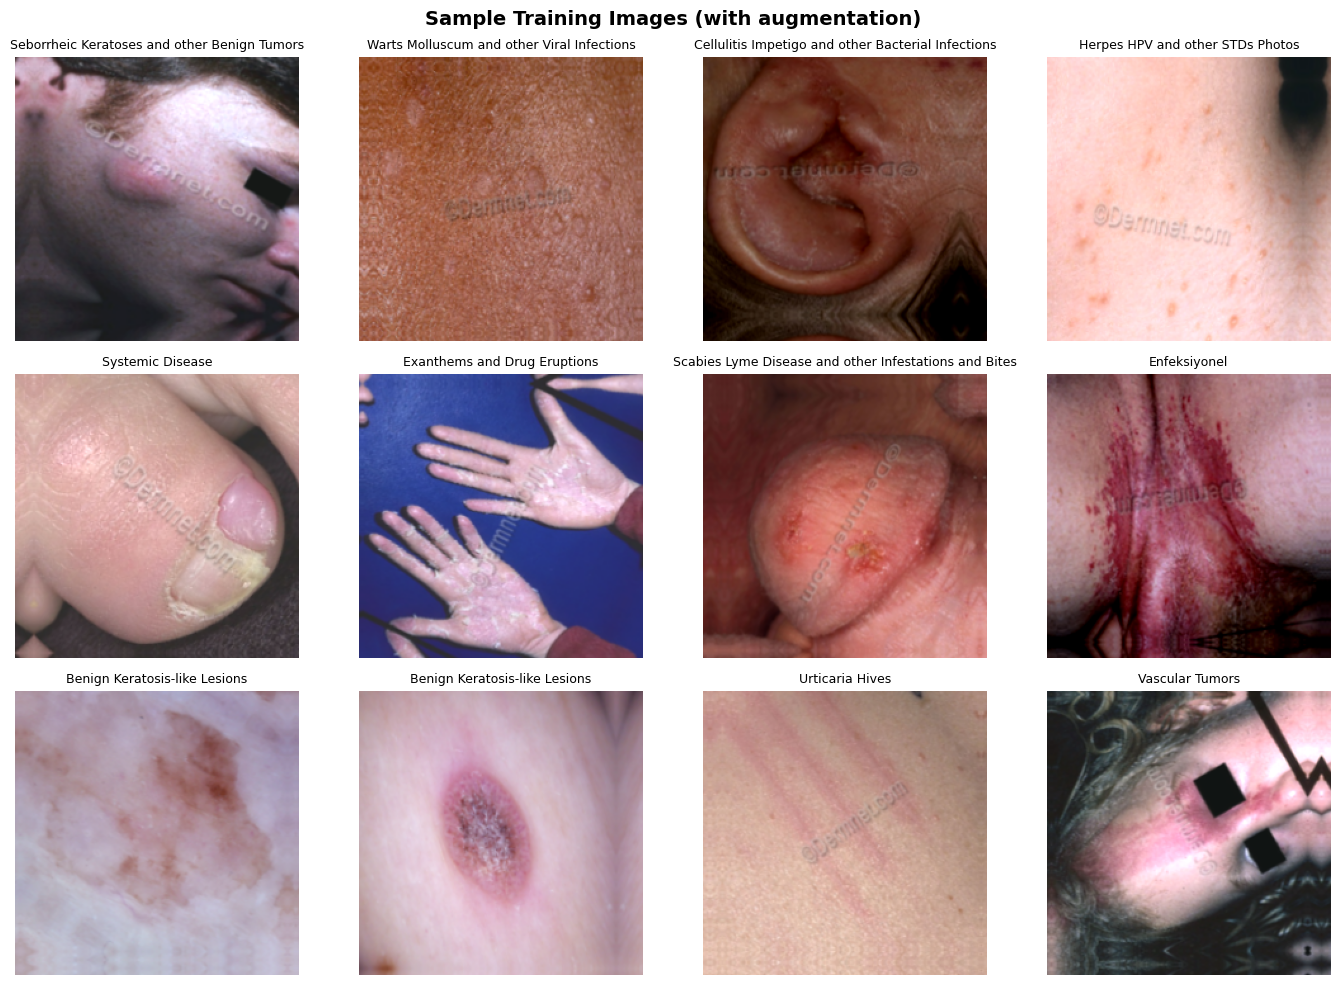

Saved → sample_images.png


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Visualize sample images (sanity check)                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt

# ── OUTPUT_DIR (not defined yet — add it here) ──
OUTPUT_DIR = "/kaggle/working/outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Grab one batch from train_ds ──
sample_images, sample_labels = next(iter(train_ds))

# Cast to uint8 for display (float32 → 0-255)
sample_images = tf.clip_by_value(sample_images[:12], 0, 255).numpy().astype("uint8")
sample_labels = tf.argmax(sample_labels[:12], axis=1).numpy()

# ── Plot 3×4 grid ──
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Sample Training Images (with augmentation)", fontsize=14, fontweight="bold")

for ax, img, lbl in zip(axes.flat, sample_images, sample_labels):
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[lbl], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "sample_images.png", dpi=120)
plt.show()
print("Saved → sample_images.png")

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Class weights (handles imbalanced data)                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np

# ── NUM_CLASSES pulled from CLASS_NAMES (defined in Cell 4) ──
NUM_CLASSES = len(CLASS_NAMES)   # 30
print(f"Number of classes : {NUM_CLASSES}")

def compute_class_weights(train_dir, num_classes):
    counts = np.zeros(num_classes, dtype=np.int64)
    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    for i, cls in enumerate(classes):
        counts[i] = len(os.listdir(os.path.join(train_dir, cls)))

    total = counts.sum()
    weights = {i: total / (num_classes * max(c, 1))
               for i, c in enumerate(counts)}
    return weights, counts


CLASS_WEIGHTS, CLASS_COUNTS = compute_class_weights(TRAIN_DIR, NUM_CLASSES)

# ── Print class distribution ──
print(f"\n{'Class':<30} {'Count':>7}  {'Weight':>7}")
print("-" * 50)
for i, (name, count) in enumerate(zip(CLASS_NAMES, CLASS_COUNTS)):
    print(f"{name:<30} {count:>7}  {CLASS_WEIGHTS[i]:>7.3f}")

print(f"\nMin weight : {min(CLASS_WEIGHTS.values()):.3f}")
print(f"Max weight : {max(CLASS_WEIGHTS.values()):.3f}")
print(f"Total images in train : {CLASS_COUNTS.sum()}")

Number of classes : 30

Class                            Count   Weight
--------------------------------------------------
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions     140    1.067
Akne                               140    1.067
Atopic Dermatitis                  140    1.067
Basal Cell Carcinoma               140    1.067
Benign Keratosis-like Lesions      140    1.067
Bullous Disease Photos             140    1.067
Cellulitis Impetigo and other Bacterial Infections     140    1.067
Eczema                             140    1.067
Enfeksiyonel                       210    0.711
Exanthems and Drug Eruptions       140    1.067
Hair Loss Photos Alopecia and other Hair Diseases     140    1.067
Herpes HPV and other STDs Photos     140    1.067
Light Diseases and Disorders of Pigmentation     140    1.067
Lupus and other Connective Tissue diseases     140    1.067
Melanocytic Nevi                   140    1.067
Melanoma                           140    1.067
Nail F

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Focal loss definition                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def focal_loss(gamma=2.0, label_smoothing=0.1):
    def loss_fn(y_true, y_pred):
        # Cast to float32 — mixed precision returns float16 logits
        # Loss must always be computed in float32
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        n   = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_t = y_true * (1.0 - label_smoothing) + (label_smoothing / n)
        y_p = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce  = -tf.reduce_sum(y_t * tf.math.log(y_p), axis=-1)
        p_t = tf.reduce_sum(y_t * y_p, axis=-1)
        return tf.reduce_mean(tf.pow(1.0 - p_t, gamma) * ce)
    return loss_fn

print("Focal loss defined ✓")
print(f"  gamma           : 2.0  (penalises easy examples)")
print(f"  label_smoothing : 0.1  (prevents overconfident softmax)")
print(f"  float32 cast    : ✓    (safe for mixed precision)")

Focal loss defined ✓
  gamma           : 2.0  (penalises easy examples)
  label_smoothing : 0.1  (prevents overconfident softmax)
  float32 cast    : ✓    (safe for mixed precision)


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Build model inside strategy.scope()                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import optimizers

def build_model(num_classes, dropout, trainable_base=False):
    base = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = trainable_base

    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=trainable_base)
    x   = L.GlobalAveragePooling2D()(x)
    x   = L.BatchNormalization()(x)
    x   = L.Dropout(dropout)(x)
    x   = L.Dense(512, activation="relu",
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x   = L.Dropout(dropout / 2)(x)
    # dtype=float32 keeps output stable with mixed_float16 policy
    out = L.Dense(num_classes, activation="softmax",
                  dtype="float32", name="predictions")(x)
    return tf.keras.Model(inp, out)


with strategy.scope():
    model = build_model(NUM_CLASSES, DROPOUT, trainable_base=False)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
        loss=focal_loss(gamma=2.0, label_smoothing=LABEL_SMOOTH),
        metrics=[
            "accuracy",
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
        ],
    )

model.summary(show_trainable=True)

frozen  = sum(1 for l in model.layers if not l.trainable)
total_p = model.count_params()
train_p = sum(np.prod(v.shape) for v in model.trainable_variables)

print(f"\nTotal params     : {total_p:,}")
print(f"Trainable params : {train_p:,}  (head only — backbone frozen)")
print(f"Frozen layers    : {frozen}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb3 (Functional) │ (None, 7, 7, 1536)    │ 10,783,535 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1536)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 1536)          │      6,144 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1536)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 512)           │    786,944 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ predictions (Dense)         │ (None, 30)            │     15,390 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 11,592,013 (44.22 MB)

 Trainable params: 805,406 (3.07 MB)

 Non-trainable params: 10,786,607 (41.15 MB)


Total params     : 11,592,013
Trainable params : 805,406  (head only — backbone frozen)
Frozen layers    : 1


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Callbacks                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from tensorflow.keras import callbacks

def get_callbacks(phase):
    ckpt_path = OUTPUT_DIR + f"best_phase{phase}.keras"
    return [
        callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=MIN_LR,        # ← from Cell 3
            verbose=1,
        ),
        callbacks.CSVLogger(OUTPUT_DIR + f"history_phase{phase}.csv"),
        callbacks.TensorBoard(
            log_dir=OUTPUT_DIR + f"tb_logs/phase{phase}",
            histogram_freq=0,
            update_freq="epoch",
        ),
    ]

print("Callbacks ready ✓")
print(f"Checkpoints will save to : {OUTPUT_DIR}")

Callbacks ready ✓
Checkpoints will save to : /kaggle/working/outputs/


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Phase 1 : Train head only (backbone frozen)                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 60)
print("PHASE 1 — Head-only training  (backbone frozen)")
print("=" * 60)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,         # ← from Cell 3
    class_weight=CLASS_WEIGHTS,   # ← from Cell 6
    callbacks=get_callbacks(phase=1),
    verbose=1,
)

print(f"\nPhase 1 complete.")
print(f"  Best val accuracy : {max(history1.history['val_accuracy']):.4f}")
print(f"  Best val top3_acc : {max(history1.history['val_top3_acc']):.4f}")

PHASE 1 — Head-only training  (backbone frozen)
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replic

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Phase 2 : Full fine-tune (low LR, all layers unfrozen)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 60)
print("PHASE 2 — Full fine-tuning  (all layers unfrozen)")
print("=" * 60)

with strategy.scope():
    # Unfreeze everything except BatchNorm
    for layer in model.layers:
        if not isinstance(layer, L.BatchNormalization):
            layer.trainable = True

    # Must recompile after changing trainability
    model.compile(
        optimizer=optimizers.Adam(learning_rate=PHASE2_LR),
        loss=focal_loss(gamma=2.0, label_smoothing=LABEL_SMOOTH),
        metrics=[
            "accuracy",
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
        ],
    )

train_p2 = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable params (Phase 2) : {train_p2:,}  (full network)")

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS + PHASE2_EPOCHS,   # e.g. 20+30 = 50 total
    initial_epoch=PHASE1_EPOCHS,            # continues from epoch 20
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks(phase=2),
    verbose=1,
)

print(f"\nPhase 2 complete.")
print(f"  Best val accuracy : {max(history2.history['val_accuracy']):.4f}")
print(f"  Best val top3_acc : {max(history2.history['val_top3_acc']):.4f}")  # ← added

PHASE 2 — Full fine-tuning  (all layers unfrozen)
Trainable params (Phase 2) : 11,501,638  (full network)
Epoch 11/50
INFO:tensorflow:Collective all_reduce tensors: 344 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.2042 - loss: 3.1940 - top3_acc: 0.3819
Epoch 11: val_accuracy improved from None to 0.40312, saving model to /kaggle/working/outputs/best_phase2.keras

Epoch 11: finished saving model to /kaggle/working/outputs/best_phase2.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 207s 785ms/step - accuracy: 0.2487 - loss: 2.9350 - top3_acc: 0.4375 - val_accuracy: 0.4031 - val_loss: 4.2643 - val_top3_acc: 0.6198 - learning_rate: 1.0000e-04
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.4511 - loss: 1.9001 - top3_acc: 0.6753
Epoch 12: val_accuracy did not improve from 0.40312
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 599ms/step - accuracy: 0.4589 - loss: 1.8629 - top3_acc: 0

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Load best checkpoint & evaluate on test set                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from sklearn.metrics import classification_report

print("=" * 60)
print("EVALUATION — Test set")
print("=" * 60)

with strategy.scope():
    best_model = tf.keras.models.load_model(
        OUTPUT_DIR + "best_phase2.keras",
        custom_objects={"loss_fn": focal_loss()}   # ← fix: inner fn name
    )

test_loss, test_acc, test_top3 = best_model.evaluate(test_ds, verbose=1)

print(f"\n{'Test Loss':<20} : {test_loss:.4f}")
print(f"{'Test Accuracy':<20} : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'Test Top-3 Acc':<20} : {test_top3:.4f}  ({test_top3*100:.2f}%)")

# ── Collect predictions ──
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds,  axis=1).numpy())

print("\n── Per-class classification report ──────────────────────────")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,   # ← Cell 4
    digits=4
))

EVALUATION — Test set
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.4042 - loss: 4.1585 - top3_acc: 0.6271

Test Loss            : 4.1585
Test Accuracy        : 0.4042  (40.42%)
Test Top-3 Acc       : 0.6271  (62.71%)

── Per-class classification report ──────────────────────────
                                                                    precision    recall  f1-score   support

Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions     0.2759    0.2667    0.2712        30
                                                              Akne     0.8462    0.3667    0.5116        30
                                                 Atopic Dermatitis     0.2381    0.1667    0.1961        30
                                              Basal Cell Carcinoma     0.2889    0.4333    0.3467        30
                                     Benign Keratosis-like Lesions     0.8519    0.7667    0.8070        30
                                            Bullous Disease 

Phase 1 actual epochs : 10
Phase 2 actual epochs : 9
Total epochs plotted  : 19


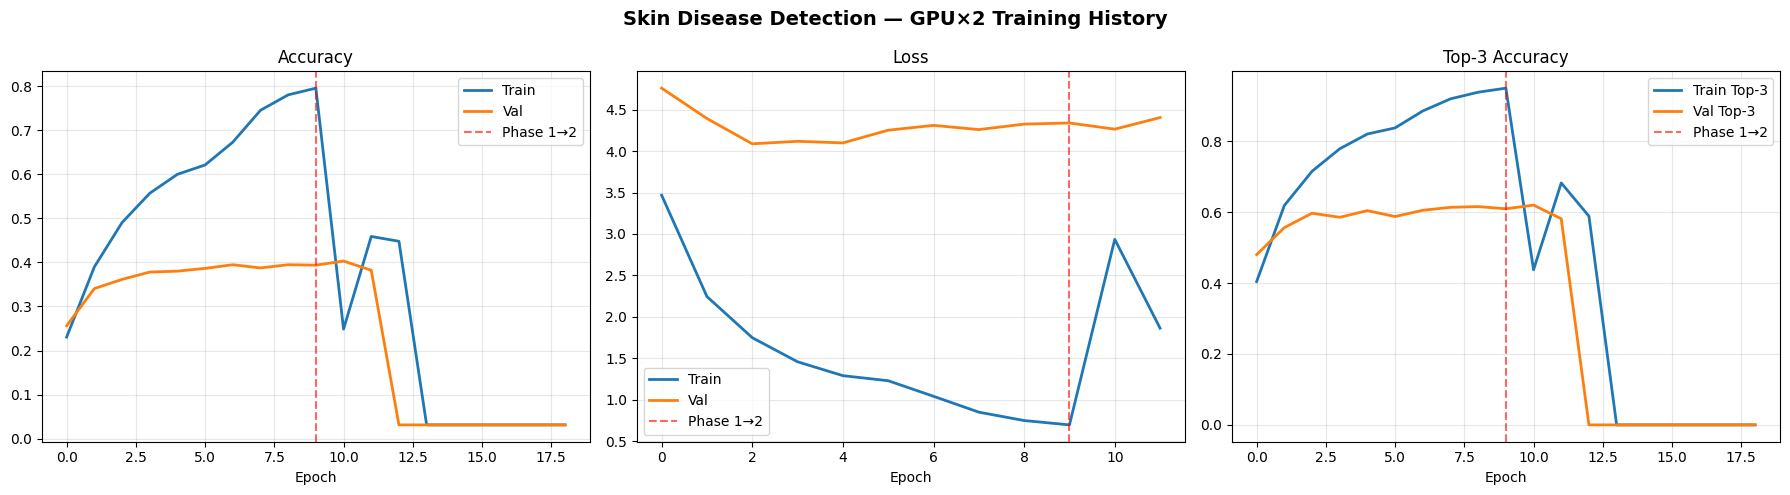

Saved → /kaggle/working/outputs/training_curves.png


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Training curves                                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt

def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

H = merge_histories(history1, history2)

# ── Use actual phase 1 length in case EarlyStopping cut it short ──
phase1_actual = len(history1.history["accuracy"])   # ← fix
total_epochs  = len(H["accuracy"])

print(f"Phase 1 actual epochs : {phase1_actual}")
print(f"Phase 2 actual epochs : {len(history2.history['accuracy'])}")
print(f"Total epochs plotted  : {total_epochs}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Skin Disease Detection — GPU×2 Training History",
             fontsize=14, fontweight="bold")

# ── Accuracy ──
axes[0].plot(H["accuracy"],     label="Train", linewidth=2)
axes[0].plot(H["val_accuracy"], label="Val",   linewidth=2)
axes[0].axvline(phase1_actual - 1, color="red", linestyle="--",
                alpha=0.6, label="Phase 1→2")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(H["loss"],     label="Train", linewidth=2)
axes[1].plot(H["val_loss"], label="Val",   linewidth=2)
axes[1].axvline(phase1_actual - 1, color="red", linestyle="--",
                alpha=0.6, label="Phase 1→2")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Top-3 Accuracy ──
axes[2].plot(H["top3_acc"],     label="Train Top-3", linewidth=2)
axes[2].plot(H["val_top3_acc"], label="Val Top-3",   linewidth=2)
axes[2].axvline(phase1_actual - 1, color="red", linestyle="--",
                alpha=0.6, label="Phase 1→2")
axes[2].set_title("Top-3 Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "training_curves.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}training_curves.png")

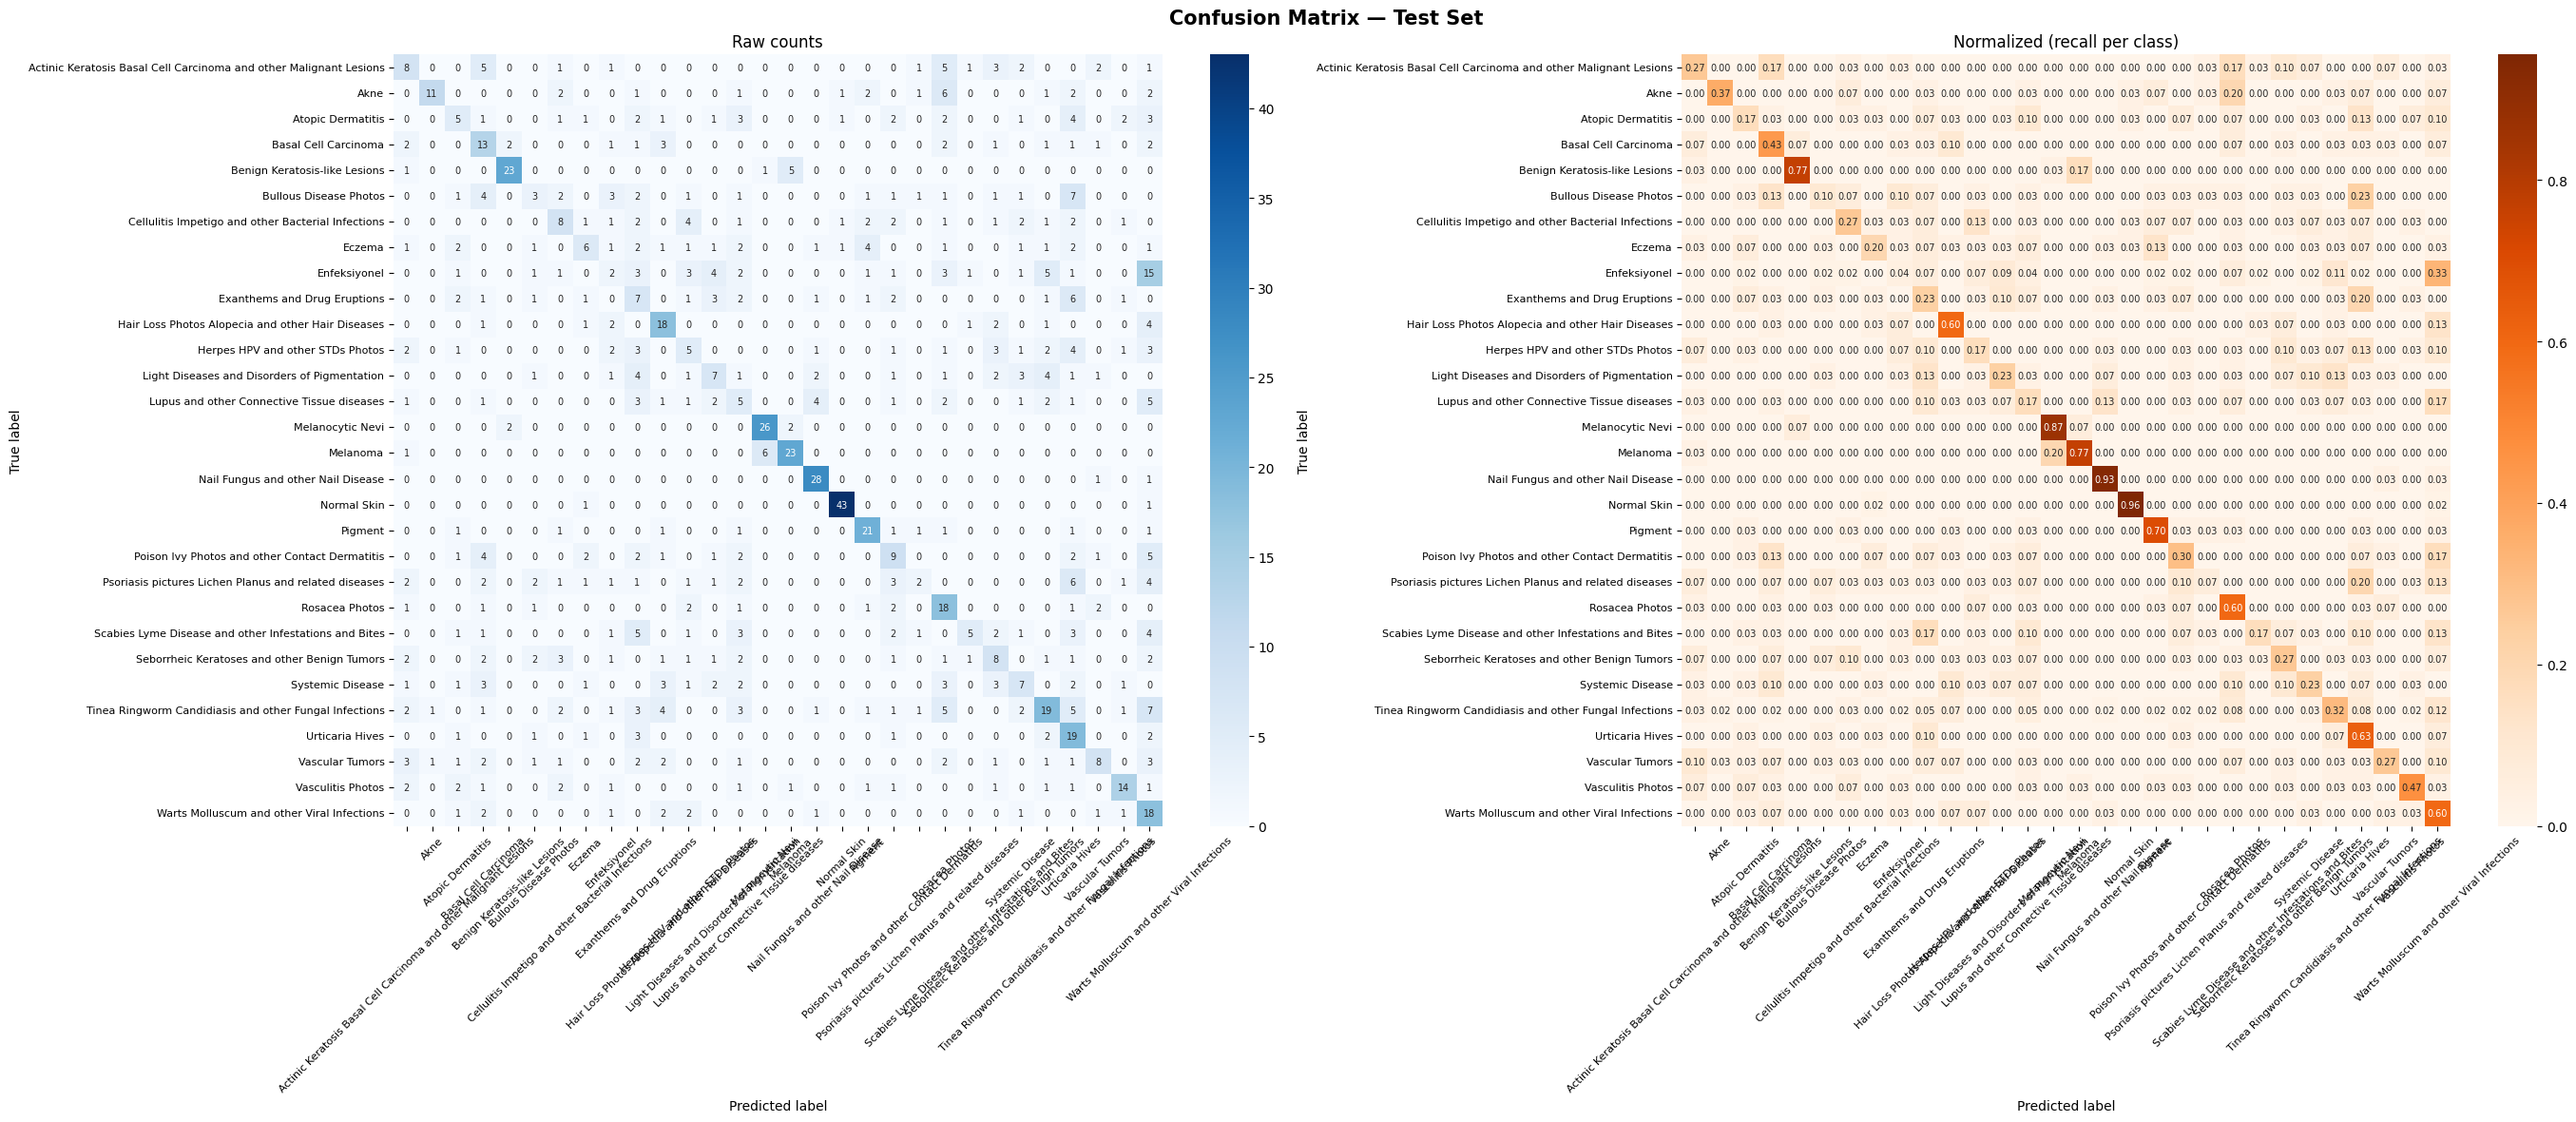

Saved → confusion_matrix.png


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Confusion matrix                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

# Normalized confusion matrix (shows recall per class)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(28, 12))
fig.suptitle("Confusion Matrix — Test Set", fontsize=15, fontweight="bold")

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={"size": 7})
axes[0].set_title("Raw counts")
axes[0].set_ylabel("True label"); axes[0].set_xlabel("Predicted label")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

# Normalized (recall)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={"size": 7})
axes[1].set_title("Normalized (recall per class)")
axes[1].set_ylabel("True label"); axes[1].set_xlabel("Predicted label")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "confusion_matrix.png", dpi=150)
plt.show()
print("Saved → confusion_matrix.png")



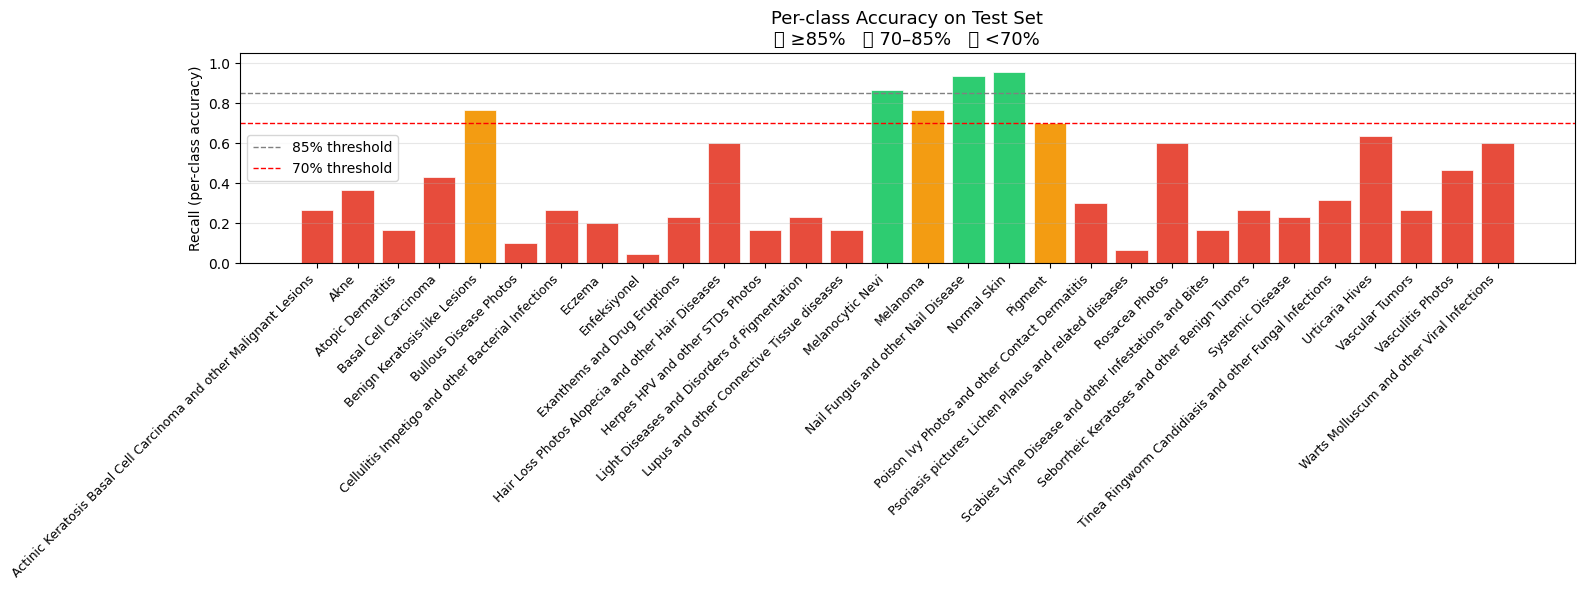


Classes below 70% accuracy (need more data / attention):
  ⚠  Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions 26.67%
  ⚠  Akne                           36.67%
  ⚠  Atopic Dermatitis              16.67%
  ⚠  Basal Cell Carcinoma           43.33%
  ⚠  Bullous Disease Photos         10.00%
  ⚠  Cellulitis Impetigo and other Bacterial Infections 26.67%
  ⚠  Eczema                         20.00%
  ⚠  Enfeksiyonel                   4.44%
  ⚠  Exanthems and Drug Eruptions   23.33%
  ⚠  Hair Loss Photos Alopecia and other Hair Diseases 60.00%
  ⚠  Herpes HPV and other STDs Photos 16.67%
  ⚠  Light Diseases and Disorders of Pigmentation 23.33%
  ⚠  Lupus and other Connective Tissue diseases 16.67%
  ⚠  Poison Ivy Photos and other Contact Dermatitis 30.00%
  ⚠  Psoriasis pictures Lichen Planus and related diseases 6.67%
  ⚠  Rosacea Photos                 60.00%
  ⚠  Scabies Lyme Disease and other Infestations and Bites 16.67%
  ⚠  Seborrheic Keratoses and other Benign Tumor

In [20]:



# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Per-class accuracy bar chart                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Shows which of the 30 classes the model finds easiest / hardest.
Helps decide which classes need more data or augmentation.
"""

per_class_acc = cm_norm.diagonal()

plt.figure(figsize=(16, 6))
colors = ["#e74c3c" if a < 0.7 else "#f39c12" if a < 0.85 else "#2ecc71"
          for a in per_class_acc]
bars = plt.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor="white", linewidth=0.5)
plt.axhline(0.85, color="gray", linestyle="--", linewidth=1, label="85% threshold")
plt.axhline(0.70, color="red",  linestyle="--", linewidth=1, label="70% threshold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Recall (per-class accuracy)")
plt.title("Per-class Accuracy on Test Set\n🟢 ≥85%   🟡 70–85%   🔴 <70%", fontsize=13)
plt.ylim(0, 1.05); plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "per_class_accuracy.png", dpi=150)
plt.show()

print("\nClasses below 70% accuracy (need more data / attention):")
weak = [(CLASS_NAMES[i], f"{v:.2%}") for i, v in enumerate(per_class_acc) if v < 0.70]
for name, acc in weak:
    print(f"  ⚠  {name:<30} {acc}")


In [21]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Save & export model                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Three formats saved to /kaggle/working/ (downloadable from Output tab):

  1. best_phase2.keras   — already saved by ModelCheckpoint during training
  2. skin_disease_final.keras  — final model after Phase 2
  3. saved_model/         — TF SavedModel for deployment / TFServing / ONNX
"""

# Save final model
final_keras = OUTPUT_DIR + "skin_disease_final.keras"
best_model.save(final_keras)
print(f"Keras model saved   : {final_keras}")

# Export SavedModel (for deployment)
saved_model_path = OUTPUT_DIR + "saved_model/"
best_model.export(saved_model_path)
print(f"SavedModel exported : {saved_model_path}")

# Save class names mapping
import json
class_map = {str(i): name for i, name in enumerate(CLASS_NAMES)}
with open(OUTPUT_DIR + "class_names.json", "w") as f:
    json.dump(class_map, f, indent=2)
print(f"Class map saved     : {OUTPUT_DIR}class_names.json")

# Final summary
print("\n" + "=" * 60)
print("✅  TRAINING COMPLETE — GPU × 2")
print("=" * 60)
print(f"  Best val accuracy   : {max(H['val_accuracy']):.4f}  "
      f"({max(H['val_accuracy'])*100:.2f}%)")
print(f"  Final test accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Final test top-3    : {test_top3:.4f}  ({test_top3*100:.2f}%)")
print(f"  Total epochs trained: {total_epochs}")
print(f"  Outputs saved to    : {OUTPUT_DIR}")
print("=" * 60)

Keras model saved   : /kaggle/working/outputs/skin_disease_final.keras
INFO:tensorflow:Assets written to: /kaggle/working/outputs/saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/outputs/saved_model/assets


Saved artifact at '/kaggle/working/outputs/saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  139495154259664: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  139510173061904: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  139510173061136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173062480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173063824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173063440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173062288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173064400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173065168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139510173065936: TensorSpec(shape=(), dtype=

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Push ALL outputs to Google Drive (Kaggle compatible)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Step 1 — Install ──
!pip install -q pydrive2

import os, json
from pydrive2.auth        import GoogleAuth
from pydrive2.drive       import GoogleDrive
from pydrive2.auth        import ServiceAccountCredentials

# ── Step 2 — Authenticate using Kaggle Secret ──
"""
One-time setup (do this BEFORE running):
  1. Go to  https://console.cloud.google.com/
  2. Create a project → Enable Google Drive API
  3. Create a Service Account → Download JSON key
  4. Go to Google Drive → share your Drive folder with the service account email
  5. In Kaggle notebook → Add-ons → Secrets →
       Key   : GDRIVE_CREDENTIALS
       Value : paste the entire contents of the JSON key file
"""

from kaggle_secrets import UserSecretsClient

secrets      = UserSecretsClient()
creds_json   = secrets.get_secret("GDRIVE_CREDENTIALS")

# Write credentials to temp file
CREDS_PATH = "/tmp/gdrive_credentials.json"
with open(CREDS_PATH, "w") as f:
    f.write(creds_json)

print("✅ Credentials loaded from Kaggle Secrets")

# ── Step 3 — Authenticate with Google Drive ──
scope  = ["https://www.googleapis.com/auth/drive"]
gauth  = GoogleAuth()
gauth.credentials = ServiceAccountCredentials.from_json_keyfile_name(
    CREDS_PATH, scope
)
drive = GoogleDrive(gauth)
print("✅ Authenticated with Google Drive")

# ── Step 4 — Create folder in Google Drive ──
DRIVE_FOLDER_NAME = "SkinDisease_30Class_Outputs"

folder = drive.CreateFile({
    "title"    : DRIVE_FOLDER_NAME,
    "mimeType" : "application/vnd.google-apps.folder"
})
folder.Upload()
folder_id = folder["id"]

print(f"✅ Created Drive folder : '{DRIVE_FOLDER_NAME}'")
print(f"   Folder ID            : {folder_id}")

# ── Step 5 — Collect all files from OUTPUT_DIR ──
all_files = []
for root, dirs, files in os.walk(OUTPUT_DIR):
    for fname in files:
        all_files.append(os.path.join(root, fname))

print(f"\n📦 Files to upload : {len(all_files)}")
for fp in all_files:
    size_mb = os.path.getsize(fp) / (1024 * 1024)
    print(f"   {os.path.basename(fp):<45} {size_mb:>7.2f} MB")

total_mb = sum(os.path.getsize(f) for f in all_files) / (1024 * 1024)
print(f"\n   Total size : {total_mb:.2f} MB")

# ── Step 6 — Upload every file ──
print("\n🚀 Uploading to Google Drive...")
print("-" * 55)

success, failed = [], []

for filepath in all_files:
    try:
        # Flatten subfolder paths → safe filename
        rel_name  = os.path.relpath(filepath, OUTPUT_DIR)
        flat_name = rel_name.replace("/

In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Zip ALL outputs and download directly to your PC                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os, zipfile
from IPython.display import FileLink, display

# ── Step 1 — Zip everything in OUTPUT_DIR ──
ZIP_PATH = "/kaggle/working/skin_disease_outputs.zip"

print("📦 Zipping all output files...")
print("-" * 50)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for fname in files:
            filepath  = os.path.join(root, fname)
            arcname   = os.path.relpath(filepath, OUTPUT_DIR)
            zipf.write(filepath, arcname)
            size_mb   = os.path.getsize(filepath) / (1024 * 1024)
            print(f"  ✅  {arcname:<45} {size_mb:>6.2f} MB")

# ── Step 2 — Show zip size ──
zip_size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print("-" * 50)
print(f"\n✅ Zip created : {ZIP_PATH}")
print(f"   Total size  : {zip_size_mb:.2f} MB")

# ── Step 3 — Download link (works in Kaggle notebook) ──
print("\n⬇  Click the link below to download:\n")
display(FileLink("/kaggle/working/skin_disease_outputs.zip"))


📦 Zipping all output files...
--------------------------------------------------
  ✅  best_phase2.keras                             221.50 MB
  ✅  best_phase1.keras                              57.82 MB
  ✅  skin_disease_final.keras                      221.48 MB
  ✅  history_phase1.csv                              0.00 MB
  ✅  class_names.json                                0.00 MB
  ✅  sample_images.png                               1.77 MB
  ✅  history_phase2.csv                              0.00 MB
  ✅  training_curves.png                             0.15 MB
  ✅  per_class_accuracy.png                          0.28 MB
  ✅  confusion_matrix.png                            0.62 MB
  ✅  tb_logs/phase1/validation/events.out.tfevents.1774780109.04b9a2b3cb65.55.1.v2   0.00 MB
  ✅  tb_logs/phase1/train/events.out.tfevents.1774780050.04b9a2b3cb65.55.0.v2   0.34 MB
  ✅  tb_logs/phase2/validation/events.out.tfevents.1774780474.04b9a2b3cb65.55.3.v2   0.00 MB
  ✅  tb_logs/phase2/train/events.ou

/kaggle/working/skin_disease_outputs.zip

In [ ]:
# Force browser download from inside Kaggle
import base64, os
from IPython.display import HTML

ZIP_PATH = "/kaggle/working/skin_disease_outputs.zip"

# Read zip and encode to base64
with open(ZIP_PATH, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

# Create download button
html = f"""
<a href="data:application/zip;base64,{b64}"
   download="skin_disease_outputs.zip"
   style="
     display: inline-block;
     padding: 12px 24px;
     background: #2ecc71;
     color: white;
     font-size: 16px;
     font-weight: bold;
     border-radius: 8px;
     text-decoration: none;
   ">
   ⬇ Download skin_disease_outputs.zip (538 MB)
</a>
"""
display(HTML(html))